# 🦸 在 DGX Spark 上构建 OpenClaw + ComfyUI 超级英雄照片生成 Workshop

<img src="imgs/dgx-spark-claw-r3.png" alt="DGX Spark Build A Claw Workshop" width="532" height="299">

> 一份"边讲边做"的 Jupyter 讲义。从一台**完全空白**的 DGX Spark 开始，60 分钟内完成：
>
> 1. 装好本地大模型（Ollama + Qwen3.6 35B）
> 2. 装好图像生成引擎（ComfyUI + FLUX + PuLID）
> 3. 装好 Agent 平台（OpenClaw）并接到 Ollama
> 4. **现场手写一个 Skill**，让 Agent 学会"把用户的自拍变成超级英雄照"
> 5. 在 OpenClaw Web UI 里对话验证

整套都跑在本地，**不需要外网**。所有文件操作只发生在 **`build_a_claw_workshop/`** 这个目录里——
ComfyUI、OpenClaw home、Skill、jupyter venv、node22 全部住在这里，删除目录就等于完全卸载，
不会污染你 `$HOME` 或系统目录。


## 端口约定 + 访问方式

| 服务 | 端口 | 跨机访问 |
|------|------|---|
| **Jupyter** | 8888 | ✅ 浏览器直接 `http://<spark-ip>:8888/lab/tree/workshop.ipynb` |
| **ComfyUI** | **8200** | ✅ 浏览器直接 `http://<spark-ip>:8200` |
| **OpenClaw chat UI** | **3030** | ✅ 浏览器直接 `http://<spark-ip>:3030/#token=...` (3.3 节会打印完整 URL) |
| Ollama | 11434 | 内部用,无 web UI |

> OpenClaw 2026.5.x 默认要求 secure context (HTTPS/localhost),3.1 节的配置会
> 显式打开 `gateway.controlUi.allowInsecureAuth=true` 并把本机 LAN IP 加进
> `allowedOrigins`,所以局域网内 HTTP 直连也能通过 device pairing。

## 大纲

| 章 | 内容 | 时间 |
|---|------|------|
| 0 | 环境检查 | 3 min |
| 1 | 安装 Ollama + 加载 Qwen3.6 模型 | 5 min |
| 2 | 部署 ComfyUI（venv 修复 + 启动） | 10 min |
| 3 | 安装 OpenClaw + 接 Ollama | 10 min |
| **4** | **现场创建 Superhero Skill** | **25 min** |
| 5 | 端到端测试 | 5 min |

## 架构

```
   浏览器 (你的笔记本)                       DGX Spark
        │                                    
        ▼                            ┌───────────────────────────┐
  http://spark:3030     ─────────►   │  OpenClaw Gateway :3030   │
                                     │  (bundle/openclaw)        │
                                     └───────────┬───────────────┘
                                                 │ skill
                                  ┌──────────────┴──────────────┐
                                  ▼                             ▼
                         ┌─────────────────┐          ┌─────────────────┐
                         │ Ollama  :11434  │          │ ComfyUI  :8200  │
                         │ qwen3.6:35b     │          │ FLUX + PuLID    │
                         └─────────────────┘          │ (bundle/...)    │
                                                      └─────────────────┘
```


---

## 工作目录与端口（每次打开都先跑一下）

下面这格把 **`WORKSHOP_DIR`** 等变量塞进 notebook 进程的环境，使后续 `!shell` cell 都能引用。


In [1]:
import os, pathlib

WORKSHOP_DIR = pathlib.Path(os.path.abspath('')).resolve()
OPENCLAW_HOME = WORKSHOP_DIR / 'openclaw-home'
SKILL_DIR     = OPENCLAW_HOME / '.openclaw' / 'skills' / 'superhero'  # ⭐ skill 实际位置

os.environ['WORKSHOP_DIR']    = str(WORKSHOP_DIR)
os.environ['OPENCLAW_HOME']   = str(OPENCLAW_HOME)
os.environ['OPENCLAW_PORT']   = '3030'
os.environ['COMFYUI_PORT']    = '8200'
os.environ['COMFYUI_URL']     = 'http://127.0.0.1:8200'
os.environ['OLLAMA_API_KEY']  = 'ollama-local'
os.environ['HF_HOME']         = str(WORKSHOP_DIR / 'hf-cache')
os.environ['HF_HUB_OFFLINE']  = '1'
os.environ['PATH']            = f"{WORKSHOP_DIR}:{WORKSHOP_DIR / 'node22' / 'bin'}:" + os.environ['PATH']

print(f'WORKSHOP_DIR  = {WORKSHOP_DIR}')
print(f'OPENCLAW_HOME = {OPENCLAW_HOME}')
print(f'SKILL_DIR     = {SKILL_DIR}')

WORKSHOP_DIR  = /home/nvidia/build_a_claw_workshop
OPENCLAW_HOME = /home/nvidia/build_a_claw_workshop/openclaw-home
SKILL_DIR     = /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/skills/superhero


---

## 第 0 章 · 环境检查

全部文件内容：


In [2]:
!ls

bin	     imgs	   openclaw	   start-workshop.sh
comfyui-app  install.sh    openclaw-home   superhero_00001_.png
comfyui.log  jupyter-env   openclaw.log    uninstall.sh
comfyui.pid  node22	   openclaw.pid    wheels
docs	     node_modules  sample	   workshop-Copy1.ipynb
env.sh	     ollama	   scripts	   workshop.ipynb
hf-cache     ollama-data   skill-template  workshop-multinode.ipynb


跑一下机器自检（架构、磁盘、内存、GPU、Python、Node、端口）：


In [3]:
!bash scripts/env-check.sh

  DGX Spark Workshop - 环境检查
  [OK]   架构: aarch64 (ARM64,符合 DGX Spark)
  [OK]   OS:   Ubuntu 24.04.3 LTS
  [OK]   Kernel: 6.14.0-1015-nvidia
  [OK]   磁盘可用: 1511GB (>=80GB)
  [OK]   内存:    119GB (DGX Spark)
  [OK]   GPU:     NVIDIA GB10
  [OK]   Python:  3.12.3
  [OK]   Node.js: v22.20.0 (满足 OpenClaw 要求 >=22)
  [WARN] 端口 3030 已被占用,workshop 可能冲突;先跑 0.4 reset cell
  [WARN] 端口 8200 已被占用,workshop 可能冲突;先跑 0.4 reset cell
  [OK]   端口 11434 已在跑 (IT 已启动 jupyter/ollama 服务)
  [OK]   端口 8888 已在跑 (IT 已启动 jupyter/ollama 服务)

环境检查完成。


### 0.1 重置环境 (每次开始 workshop 都先跑一下)

> ⚠️ 一台机器可能被多个学员先后使用。这一格把上一位学员留下的状态全部清掉,
> 让你从一个**干净环境**开始 (但保留 IT 装好的二进制,不需要重装):
>
> - 停掉 ollama / comfyui / openclaw 用户进程
> - 删除 OpenClaw 配置 (`openclaw-home/`,含已批准设备 / chat history / 上一次写的 skill)
> - 清空 ComfyUI 输出图片 + 日志


In [4]:
import subprocess, os, shutil, pathlib, time

WD = os.environ['WORKSHOP_DIR']

# 1) stop ctl-managed services
for svc in ('openclaw-ctl.sh', 'comfyui-ctl.sh', 'ollama-ctl.sh'):
    subprocess.run(['bash', f'scripts/{svc}', 'stop'], cwd=WD,
                   capture_output=True, timeout=15)
# 2) belt-and-suspenders: kill anything still bound to our ports
for port in (3030, 8200, 11434):
    subprocess.run(['fuser', '-k', '-n', 'tcp', str(port)],
                   capture_output=True, timeout=5)
time.sleep(2)

# 3) wipe per-session state, keep installed binaries
for path in ['openclaw-home', '*.log', '*.pid']:
    for p in pathlib.Path(WD).glob(path):
        if p.is_dir():
            shutil.rmtree(p, ignore_errors=True)
        else:
            p.unlink(missing_ok=True)

# 4) clear comfyui outputs (so previous students' images don't appear)
out_dir = pathlib.Path(WD) / 'comfyui-app' / 'ComfyUI' / 'output'
in_dir  = pathlib.Path(WD) / 'comfyui-app' / 'ComfyUI' / 'input'
for d in [out_dir, in_dir]:
    if d.exists():
        for f in d.iterdir():
            if f.is_file() and not f.name.startswith('put_'):
                f.unlink(missing_ok=True)

print('✅ 环境已重置。已保留:')
for p in ['node22', 'ollama', 'openclaw', 'jupyter-env', 'node_modules']:
    pp = pathlib.Path(WD) / p
    print(f'   {"✓" if pp.exists() else "✗"} {p}')

print()
print('当前监听端口:')
ports = subprocess.run(['ss', '-ltn'], capture_output=True, text=True).stdout
for line in ports.splitlines():
    for p in (':3030', ':8200', ':11434', ':8888'):
        if p in line:
            print(f'   {line.strip()}')
            break

✅ 环境已重置。已保留:
   ✓ node22
   ✓ ollama
   ✓ openclaw
   ✓ jupyter-env
   ✓ node_modules

当前监听端口:
   LISTEN 0      128          0.0.0.0:8888       0.0.0.0:*
   LISTEN 0      4096               *:11434            *:*


---

## 第 1 章 · 启动 Ollama 与本地大模型

**Ollama** 是本地大模型 runtime——给一个简单的 HTTP API,后端跑量化的 LLM(我们用 Qwen3.6)。OpenClaw 后面就是把这个 API 调起来做推理。

> 📦 Ollama 的二进制和模型 blob(`qwen3.6:35b`,~23 GB)IT 已经放进 `bundle/ollama/` 和 `bundle/ollama-data/`,**你不需要装,也不需要 sudo**。这一节的任务只是 **启动** 它。

### 1.1 启动 Ollama 服务


In [5]:
!bash scripts/ollama-ctl.sh start

Ollama 已在 :11434 上运行


### 1.2 看一下 Ollama 上有哪些模型


In [6]:
!bash scripts/ollama-ctl.sh status

Ollama 运行中 (端口 11434)
]11;?\NAME                       ID              SIZE     MODIFIED     
qwen3.6:35b                07d35212591f    23 GB    6 weeks ago     
qwen35-nothink:latest      442f07ba8473    23 GB    3 months ago    
qwen3.5:35b-a3b-nothink    aed79ac5a4c2    23 GB    3 months ago    
qwen3.5:35b-a3b            3460ffeede54    23 GB    3 months ago    
nemotron-3-nano:30b        b725f1117407    24 GB    3 months ago    
nemotron-3-super:120b      95acc78b3ffd    86 GB    3 months ago    
nemotron-3-super:latest    95acc78b3ffd    86 GB    3 months ago    
qwen3.5:122b               8b9d11d807c5    81 GB    4 months ago    
qwen3.5:35b                3460ffeede54    23 GB    4 months ago    
glm-4.7-flash:latest       d1a8a26252f1    19 GB    4 months ago    
qwen3-coder-next:latest    ca06e9e4087c    51 GB    4 months ago    


### 1.3 直接用 HTTP API 试问一句话

这就是 OpenClaw 后面要走的接口，先确认它能跑：

> ⚠️ **注意 `think: false`**：Qwen3.6 是 reasoning 模型，默认会把回答塞进 `message.thinking` 而 `message.content` 是**空**的。我们传 `think:false` 关掉它，才能在 `content` 拿到真正的回答。OpenClaw 那边 3.3 节会通过 `agents.defaults.thinkingDefault=off` 全局关掉 thinking，所以 Agent 调用时不用再额外操心这个参数。


In [7]:
import requests, json
resp = requests.post(
    "http://127.0.0.1:11434/api/chat",
    json={
        "model": "qwen3.6:35b",
        "messages": [{"role": "user", "content": "用一句话告诉我你是谁。"}],
        "stream": False,
        "think": False,             # ← 关键: 关掉 reasoning 模式
    },
    timeout=60,
)
data = resp.json()
print("content :", data["message"]["content"])
print("thinking:", "(empty,正常)" if not data["message"].get("thinking") else "(非空,模型没听话)")

content : 我是通义千问，由阿里云通义实验室开发的大语言模型。
thinking: (empty,正常)


---

## 第 2 章 · 部署 ComfyUI（图片生成引擎）

**ComfyUI** 节点式扩散模型推理引擎。我们的工作流：

```
用户人脸 ──► InsightFace 识别 ──► PuLID 把"人脸身份"压成 token
                                       │
                                       ▼
        FLUX.1-dev (fp8)  +  正向 prompt(超级英雄飞行)
                                       │
                                       ▼
                              KSampler · 24 步
                                       │
                                       ▼
                          1024×1024 超级英雄照片
```

bundle 里 `comfyui-app/` 已经准备好（IT 装好的）：
- ComfyUI 源码 + `ComfyUI-PuLID-Flux` 自定义节点
- Python venv（PyTorch 2.11+cu130，~6 GB）
- 全部 AI 模型（FLUX + PuLID + InsightFace + CLIP/T5/VAE，~30 GB）

> 📦 **不需要安装,也不需要 sudo**。这一节的任务是 **启动** 它。

### 2.1 启动 ComfyUI（端口 8200）

`comfyui-ctl.sh` 是 bundle 自带的管理脚本，会用 `--fast` 模式启 ComfyUI（启用 Blackwell FP8 Tensor Core）。

> ⚠️ 第一次启动加载几十 GB 的 safetensors，**约 60-90 秒**才能听到 8200 端口；下一格的轮询会等到它就绪为止。


In [8]:
!bash scripts/comfyui-ctl.sh start

启动 ComfyUI (端口 8200)...
[ok] ComfyUI 就绪 (端口 8200, PID 123909)
     http://192.168.8.117:8200


### 2.2 等 ComfyUI 在 :8200 上就绪


In [9]:
import time, requests, json
COMFY_URL = "http://127.0.0.1:8200"
for i in range(40):
    try:
        s = requests.get(f"{COMFY_URL}/api/system_stats", timeout=3).json()
        print(json.dumps(s.get("system", {}), indent=2, ensure_ascii=False))
        break
    except Exception:
        if i % 5 == 0:
            print(f"  still warming… ({i*3}s)")
        time.sleep(3)
else:
    print("ERROR: ComfyUI 未在 120s 内就绪")
    print("  日志: bash scripts/comfyui-ctl.sh logs")

{
  "os": "linux",
  "ram_total": 128524251136,
  "ram_free": 50130989056,
  "comfyui_version": "0.18.1",
  "required_frontend_version": "1.42.8",
  "installed_templates_version": "0.9.44",
  "required_templates_version": "0.9.44",
  "python_version": "3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]",
  "pytorch_version": "2.11.0+cu130",
  "embedded_python": false,
  "argv": [
    "/home/nvidia/build_a_claw_workshop/comfyui-app/ComfyUI/main.py",
    "--listen",
    "0.0.0.0",
    "--port",
    "8200",
    "--fast"
  ]
}


### 2.3 浏览器打开 ComfyUI 看一眼工作流

> 💡 **DGX Spark 是统一内存**: Ollama 把 LLM 留在 GPU 内存里(~33 GB),
> 如果在 ComfyUI 浏览器里直接点 **Queue Prompt** 而不先腾出显存,VAE 解码会卡死。
> 下面这格在打开 ComfyUI 之前主动 unload ollama 一次,确保显存够 ComfyUI 用。
> (skill 调用路径 5.1/5.2/5.3 helper 自己会 unload,这一格是为了让你能在浏览器里直接试 workflow。)


In [10]:
import requests, socket

# 释放 ollama 占用的 GPU 显存 (skip 失败,以防 ollama 没启)
try:
    requests.post('http://127.0.0.1:11434/api/generate',
                  json={'model': 'qwen3.6:35b', 'keep_alive': 0},
                  timeout=10)
    print('✅ Ollama LLM 已卸载,GPU 显存让给 ComfyUI')
except Exception as e:
    print(f'(skipped ollama unload: {e})')

def _lan_ip():
    import socket as _sk
    s = _sk.socket(_sk.AF_INET, _sk.SOCK_DGRAM)
    try:
        s.connect(('8.8.8.8', 80)); return s.getsockname()[0]
    except Exception:
        return '127.0.0.1'
    finally:
        s.close()
ip = _lan_ip()
print()
print('═══════════════════════════════════════════════════════════')
print(f'  ComfyUI: http://{ip}:8200    (笔记本浏览器直接 LAN 访问,无需 SSH)')
print('═══════════════════════════════════════════════════════════')

✅ Ollama LLM 已卸载,GPU 显存让给 ComfyUI

═══════════════════════════════════════════════════════════
  ComfyUI: http://192.168.8.117:8200    (笔记本浏览器直接 LAN 访问,无需 SSH)
═══════════════════════════════════════════════════════════


**打开 ComfyUI 之后**（只是看一眼，**不要点 Queue Prompt**）：

1. 左侧侧栏点 **Workflow** 图标 📋 → 选 **`超级英雄变装`** —— 整张工作流加载到画布
2. 从左到右走一遍节点，理解 **PuLID + FLUX** 怎么协作：
   - `CheckpointLoaderSimple` 装 FLUX.1-dev fp8
   - `PulidFluxModelLoader` + `InsightFaceLoader` + `EvaClipLoader` 加载 PuLID 三件套
   - `LoadImage` 进人脸，`ApplyPulidFlux` 把人脸压成 identity token 喂给 FLUX
   - `CLIPTextEncode` 编码 "超级英雄飞行" 的 prompt
   - `KSampler` 24 步采样 → `VAEDecode` → `SaveImage`

> ⚠️ **不要在浏览器里点 Queue Prompt 自己生成**。
> 原因：workshop 后面的 cell 5.x 走的是 **skill 路径**（helper 会自动 unload ollama 让出显存、自动等待结果），是稳的。  
> 浏览器直接 Queue 时如果中途看着没动就点 Cancel，ComfyUI 会陷入半中断状态死锁，需要重启。  
> 真正生成图片请走 **cell 5.1 / 5.3**（命令行 + OpenClaw chat UI），下面就到。

> 📚 这个工作流就是我们的 skill 后端真正在跑的。Workshop 的目标：
> **把这套节点图包成一个一行命令的 skill**，让 OpenClaw 里的 agent 能直接调。


---

## 第 3 章 · 安装 OpenClaw 并接到 Ollama

**OpenClaw** 是开源 Agent 平台 / 多渠道网关：

- 长驻 **Gateway**（我们用 :3030 避开默认 3000）
- 自带 Web UI、CLI 和多个聊天渠道（飞书 / 微信 / Slack…）
- 业务能力以 **Skill** 为单位扩展（带 `SKILL.md` 的目录）

> 📦 OpenClaw npm 包 + Node 22 + bundle/openclaw 包装脚本 IT 都装好了,**不需要 sudo**。这一节的任务是 **配置 + 启动 + 浏览器对话**。

先看一眼 bundle 自带的 OpenClaw CLI:


In [11]:
!./openclaw --version

OpenClaw 2026.5.19 (a185ca2)


### 3.1 初始化 OpenClaw home（写入 bundle 内）

OpenClaw 把所有状态放在 `OPENCLAW_HOME` 下面的 `.openclaw/`：

```
$OPENCLAW_HOME/
└── .openclaw/
    ├── openclaw.json       # 主配置
    ├── workspace/          # Agent 身份、规则
    └── skills/             # ⭐ 等下我们要把 skill 写到这里
```

第一次运行 `openclaw onboard` 会自动生成这套结构（包含一份合理的默认配置），然后我们用 `openclaw config set` 把模型换成 Ollama 的 qwen3.6：


In [12]:
import subprocess, os, pathlib, json

WD = os.environ['WORKSHOP_DIR']

# 1) bootstrap config (idempotent — 已存在就只刷新 wizard 元数据)
subprocess.run([
    './openclaw', 'onboard',
    '--non-interactive', '--accept-risk',
    '--mode', 'local',
    '--skip-health',
], cwd=WD, check=True)

# 2) patch: 默认模型换成本地 Ollama 的 qwen3.6:35b;端口 3030;
#    bind=lan 让局域网(你的笔记本)能访问 web UI;
#    tools.profile=messaging 关掉 read/write/exec 等工具——这个 demo 只需要
#    agent 调用我们的 superhero skill 并回话,不应该让它去 fs/shell 操作
#    (如果留 coding profile,agent 会把 MEDIA: 路径误识别成"要执行的脚本")
for k, v in [
    ('agents.defaults.model.primary', 'ollama/qwen3.6:35b'),
    ('agents.defaults.thinkingDefault', 'off'),  # qwen3.6 默认 thinking,关掉后不会把答案塞进 thinking 字段
    ('gateway.port', '3030'),
    ('gateway.bind', 'lan'),
    # OpenClaw 2026.5.x 默认要求 HTTPS/Tailscale 才允许跨机访问 control UI。
    # workshop 在可信局域网里跑 HTTP,显式打开 token-only 兼容模式。
    ('gateway.controlUi.allowInsecureAuth', 'true'),
    # ⭐ 远程 LAN HTTP 直连(非 localhost)必须再加这个:allowInsecureAuth
    #    只对 localhost 生效,真正放行任意 LAN 设备靠 dangerouslyDisableDeviceAuth。
    #    它完全跳过设备配对,任何拿到 token 的 LAN 设备都能直接连(可信局域网可接受)。
    ('gateway.controlUi.dangerouslyDisableDeviceAuth', 'true'),
]:
    subprocess.run(['./openclaw', 'config', 'set', k, v],
                   cwd=WD, check=False)

# Origin allowlist: 浏览器从 LAN IP 访问时,WebSocket Origin header 必须在白名单
# 否则 gateway 拒连(WS code 4008)。把本机 LAN IP 加上。
# 枚举本机所有 IPv4(多网卡 / 地址不固定时,任一 spark 地址都进白名单)
import subprocess as _sp
def _all_lan_ips():
    ips = set()
    try:
        out = _sp.run(['hostname', '-I'], capture_output=True, text=True, timeout=5).stdout
        for tok in out.split():
            if tok.count('.') == 3:  # IPv4 only
                ips.add(tok)
    except Exception:
        pass
    return sorted(ips)
PORT = 3030
allowed = ['http://localhost:3030', 'http://127.0.0.1:3030']
for _ip in _all_lan_ips():
    allowed.append(f'http://{_ip}:3030')
subprocess.run(['./openclaw', 'config', 'set',
                'gateway.controlUi.allowedOrigins', json.dumps(allowed)],
               cwd=WD, check=False)
# tools.profile 默认 'coding' 也带很多无关工具,直接 unset
subprocess.run(['./openclaw', 'config', 'unset', 'tools.profile'],
               cwd=WD, check=False)

# 关掉 OpenClaw 自带的 native commands (read/write/exec/message 等),
# 只保留 nativeSkills (我们的 superhero skill)。否则 agent 会拿到大量
# 通用工具去瞎用,而不调用我们写的 skill。
for k, v in [
    ('commands.native', 'false'),
    ('commands.nativeSkills', 'auto'),
]:
    subprocess.run(['./openclaw', 'config', 'set', k, v],
                   cwd=WD, check=False)

# 3) 把 qwen3.6:35b 标记为"支持图片输入"
#    — 这样 web UI 上传的附件才会被 OpenClaw 保留并把文件路径塞进 prompt;
#    否则附件被静默丢弃,日志里出现:
#    "parseMessageWithAttachments: attachment(s) dropped — model does not support images"
#    (Qwen3.6 本身不真"看"图,我们只是要拿到文件路径喂给 ComfyUI skill)
ollama_provider = json.dumps({
    'apiKey': 'ollama-local',
    'baseUrl': 'http://127.0.0.1:11434',
    'models': [{
        'id': 'qwen3.6:35b',
        'name': 'qwen3.6:35b',
        'input': ['text', 'image'],
        'contextWindow': 131072,  # Qwen3.6 实际支持 256K,这里限到 128K 避免长会话触发 compact loop
    }],
})
subprocess.run(['./openclaw', 'config', 'set',
                'models.providers.ollama', ollama_provider],
               cwd=WD, check=False)

# 4) 重写 SOUL.md — 让 agent 一开始就明确知道有 superhero skill
soul = pathlib.Path(os.environ['OPENCLAW_HOME']) / '.openclaw' / 'workspace' / 'SOUL.md'
soul.parent.mkdir(parents=True, exist_ok=True)
soul.write_text('''# SOUL.md

你是一个跑在 NVIDIA DGX Spark 本机上的多模态 Agent。
你的核心能力是 **superhero** skill — 把用户的自拍生成超级英雄风格肖像。

## 行为规则

1. 当用户说"生成超级英雄照片"、"超级英雄"、"超人变装"、"superhero" 等关键词,
   或发送一张人脸照片希望变身时,**必须**调用你本地的 superhero skill。
   绝对**不要**推荐 Pixlio、Media.io、Midjourney 等任何在线工具——你有本地能力,
   全程离线就能完成。

2. 如果用户**没有附带照片**,礼貌地索取一张正面自拍:
   "请发一张你的正面照片,我用本地 ComfyUI 帮你生成超级英雄版本"。
   不要先发废话,只问那一句即可。

3. 拿到照片后,直接执行 superhero skill 的命令。命令成功的 stdout 会有一行
   `MEDIA:<绝对路径>`。**把这整行原样复制进你的回复**——OpenClaw 看到 `MEDIA:`
   前缀会把那个文件作为附件渲染到聊天里。**不要**用 markdown `![](...)`,
   **不要**改路径或加 `~/`。正确格式:
   ```
   你的超级英雄照片来啦!
   MEDIA:/home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/workspace/outputs/superhero_xxx.png
   ```

4. 用简洁中文回答,不要泄露内部脚本路径或文件系统细节。
''', encoding='utf-8')
print('SOUL.md 已写入:', soul)

print()
print('OpenClaw home 已初始化 + 模型已切换 + SOUL.md 强化:')
!ls $OPENCLAW_HOME/.openclaw/

Updated config: $OPENCLAW_HOME/.openclaw/openclaw.json
Workspace OK: $OPENCLAW_HOME/.openclaw/workspace
Sessions OK: $OPENCLAW_HOME/.openclaw/agents/main/sessions
Tip: run `openclaw configure --section web` to store your Brave API key for web_search. Docs: https://docs.openclaw.ai/tools/web
Updated agents.defaults.model.primary. Restart the gateway to apply.
Updated agents.defaults.thinkingDefault. Restart the gateway to apply.
Updated gateway.port. Restart the gateway to apply.
Updated gateway.bind. Restart the gateway to apply.
Updated gateway.controlUi.allowInsecureAuth. Restart the gateway to apply.
Updated gateway.controlUi.dangerouslyDisableDeviceAuth. Restart the gateway to apply.
Updated gateway.controlUi.allowedOrigins. Restart the gateway to apply.
Removed tools.profile. Restart the gateway to apply.
Updated commands.native. Restart the gateway to apply.
Updated commands.nativeSkills. Restart the gateway to apply.
Updated models.providers.ollama. Restart the gateway to apply.

### 3.2 启动 OpenClaw gateway（端口 3030）

通过 `openclaw-ctl.sh` 启动，PID/log 都写在 bundle 根目录下。


In [13]:
!bash scripts/openclaw-ctl.sh start

启动 OpenClaw gateway (端口 3030)...
[ok] OpenClaw gateway 就绪 (PID 124259)
     http://192.168.8.117:3030


### 3.3 打开 OpenClaw Web UI 试一句对话

3.1 节的配置已经把 OpenClaw `gateway.controlUi.allowInsecureAuth=true` 打开,
并把本机 LAN IP 加进了 `allowedOrigins`,所以你笔记本浏览器可以**直接** HTTP
访问 spark 上的 OpenClaw Web UI,不需要 SSH 端口转发。

下面这格会打印出完整的 URL(含 token),复制到浏览器打开就能进入对话界面。


In [14]:
import socket, json, os, pathlib, requests

cfg = json.loads((pathlib.Path(os.environ['OPENCLAW_HOME']) / '.openclaw/openclaw.json').read_text())
token = cfg['gateway']['auth']['token']
port  = cfg['gateway']['port']
def _lan_ip():
    import socket as _sk
    s = _sk.socket(_sk.AF_INET, _sk.SOCK_DGRAM)
    try:
        s.connect(('8.8.8.8', 80)); return s.getsockname()[0]
    except Exception:
        return '127.0.0.1'
    finally:
        s.close()
ip = _lan_ip()

# 检查 gateway 是不是真的起来了 (3.2 必须先跑)
gw_ok = False
try:
    r = requests.get(f'http://127.0.0.1:{port}/', timeout=2)
    gw_ok = r.status_code == 200
except Exception:
    pass

if not gw_ok:
    print(f'❌ spark 上 :{port} 还没监听 — OpenClaw gateway 没启动。')
    print()
    print('    回到上面,先跑 3.1(初始化配置)+ 3.2(启动 gateway)这两格,')
    print('    看到 "OpenClaw gateway 就绪" 之后再跑这一格。')
    print()
    print(f'    如果 3.2 已经跑过但还是失败,看日志:')
    print(f'        bash scripts/openclaw-ctl.sh logs')
else:
    url = f'http://{ip}:{port}/#token={token}'
    print('=' * 64)
    print('🌐 在你笔记本浏览器里直接打开 (新 tab):')
    print('=' * 64)
    print()
    print(f'  {url}')
    print()
    print('=' * 64)
    print(f'  token (URL 已带,如果丢了): {token}')
    print('=' * 64)
    print()
    print(f'第一次打开浏览器会显示"批准此请求",下一格 (3.4) 会自动批准。')


🌐 在你笔记本浏览器里直接打开 (新 tab):

  http://192.168.8.117:3030/#token=83255ce4024e0fe890d04c4b4ccd282b3b11a586da20583e

  token (URL 已带,如果丢了): 83255ce4024e0fe890d04c4b4ccd282b3b11a586da20583e

第一次打开浏览器会显示"批准此请求",下一格 (3.4) 会自动批准。


### 3.4 批准设备配对（自动）
#### （注意：如果上面链接能够正常打开，此步骤不需运行）
OpenClaw 2026.5.x 给每个新浏览器单独发"设备身份"，首次连接需要 spark 端批准。
下面这格做的事：

1. **现在**就先批准已经 pending 的（如果有）
2. 然后**轮询 90 秒**等新的 pending — 学员现在去浏览器开 URL，cell 会自动检测并批准
3. 看到 "✅ approved" 后浏览器刷新或点页面"重新连接"即可

> Workshop 局域网可信，自动批所有的 pairing；生产环境请人工审。


In [15]:
import subprocess, re, os, time

WD = os.environ['WORKSHOP_DIR']
UUID_RE = re.compile(r'\b([0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12})\b')

def list_pending():
    out = subprocess.run(['./openclaw', 'devices', 'list'], cwd=WD,
                          capture_output=True, text=True, timeout=10).stdout
    in_pending = False
    ids = []
    for line in out.splitlines():
        if 'Pending' in line:
            in_pending = True; continue
        if in_pending and 'Paired' in line: break
        if in_pending:
            for m in UUID_RE.finditer(line):
                ids.append(m.group(1))
    # dedupe + preserve order
    seen = set(); uniq = []
    for i in ids:
        if i not in seen: seen.add(i); uniq.append(i)
    return uniq

def approve(rid):
    r = subprocess.run(['./openclaw', 'devices', 'approve', rid], cwd=WD,
                        capture_output=True, text=True, timeout=15)
    msg = (r.stdout + r.stderr).strip().splitlines()[-1] if (r.stdout or r.stderr) else f'rc={r.returncode}'
    return msg

approved = set()

# (a) 先把现有的 pending 全批了
for rid in list_pending():
    print(f'✅ pre-approve  {rid[:13]}…  {approve(rid)}')
    approved.add(rid)

print()
print('═══════════════════════════════════════════════════════════')
print('  现在请到笔记本浏览器打开上面 3.3 输出的 URL')
print('  Jupyter 会在后台轮询(最多 90 秒),检测到新 pairing 请求')
print('  会自动批准,你直接看浏览器刷新即可')
print('═══════════════════════════════════════════════════════════')

deadline = time.time() + 90
while time.time() < deadline:
    new = [r for r in list_pending() if r not in approved]
    if new:
        for rid in new:
            print(f'✅ approved     {rid[:13]}…  {approve(rid)}')
            approved.add(rid)
        print('   → 浏览器刷新即可,你应该看到 chat UI 了')
        break
    time.sleep(2)
else:
    print()
    print('(90 秒内没等到新 pairing 请求 — 你可能已经批过了,或还没访问 URL。')
    print(' 再次访问 URL 时如果浏览器又报"批准请求",就再跑这一格。)')


═══════════════════════════════════════════════════════════
  现在请到笔记本浏览器打开上面 3.3 输出的 URL
  Jupyter 会在后台轮询(最多 90 秒),检测到新 pairing 请求
  会自动批准,你直接看浏览器刷新即可
═══════════════════════════════════════════════════════════

(90 秒内没等到新 pairing 请求 — 你可能已经批过了,或还没访问 URL。
 再次访问 URL 时如果浏览器又报"批准请求",就再跑这一格。)


### 3.5 在浏览器里说一句"你好"

进了 chat UI 之后,对它说一句 **「你好」**。如果回复正常,说明:

- OpenClaw 启动 ✅
- Ollama 连通 ✅
- LLM 推理正常 ✅

> 现在它**还不会**生成超级英雄照片——下一章我们就给它加这个能力。

### ❓ 常见问题

| 现象 | 处理 |
|---|---|
| 浏览器打不开 `http://<spark-ip>:3030` | 确认笔记本和 spark 在同一局域网,`bash scripts/openclaw-ctl.sh status` 看 :3030 是不是真的在监听 |
| 浏览器报 `unauthorized: token mismatch` | 关掉这个 OpenClaw tab,**完整**复制 3.3 输出的整条 URL (含 `#token=...`) 重新打开 |
| 浏览器一直空白或转圈 | URL 里 `#token=...` 缺了或被截断,整段重新复制 |
| 浏览器报 `control ui requires device identity` / `不安全 HTTP 文档` | 3.1 cell 没跑或没设 `allowInsecureAuth=true`,重跑 3.1 + 3.2 |
| 浏览器显示"批准此请求" | 跑 3.4 那格自动批准,或在 OpenClaw 里手动批 |


---

## 第 4 章 · 现场创建 Superhero Skill ⭐

> 整个 workshop 最重要的一章。我们手敲 4 个文件，让 Agent 学会一项新能力。

### Skill 结构

`$OPENCLAW_HOME/.openclaw/skills/<name>/` 这个目录就是一个 Skill。OpenClaw 启动时扫描所有 skills，把它们的 **`SKILL.md`** 头喂给 LLM，让 LLM 知道：

- 这个 skill 是干嘛的（`description`）
- 什么情况下应该触发它（关键词、上下文）
- 触发后该执行哪条 shell 命令、参数怎么填

LLM 决定调用时，OpenClaw 真正去 fork 一个 shell 跑那条命令，把 stdout/stderr 喂回模型。

我们要做的 superhero skill 长这样：

```
$OPENCLAW_HOME/.openclaw/skills/superhero/
├── SKILL.md               # 给 LLM 看的"使用说明书"
├── run_helper.sh          # 入口:激活 venv,转发参数
├── superhero_helper.py    # 业务逻辑:调 ComfyUI HTTP API
└── face_workflow.json     # ComfyUI 工作流(API 格式)
```

整个 skill 目录在 `bundle/openclaw-home/.openclaw/skills/superhero/` 下，删 bundle 就等于删 skill。


### 4.1 创建 skill 目录


In [16]:
import os, pathlib
skill_dir = pathlib.Path(os.environ['OPENCLAW_HOME']) / '.openclaw' / 'skills' / 'superhero'
skill_dir.mkdir(parents=True, exist_ok=True)
print(f'mkdir -p {skill_dir}')
!ls $OPENCLAW_HOME/.openclaw/skills/

mkdir -p /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/skills/superhero
superhero


### 4.2 写 `SKILL.md`（Skill 的契约）

YAML 头里 `description` 是给 LLM 决定何时触发用的——**写得越清楚，触发越准**。
正文是命令调用规范。这就是 LLM 看到的全部内容。


In [17]:
skill_md = r"""---
name: superhero
description: "Generate a 1024x1024 superhero-style portrait from a face photo. Use when: user asks 帮我生成超级英雄照片, 超级英雄, 超人, 变装, superhero photo, or sends a face photo asking for a hero look."
metadata: { "openclaw": { "emoji": "🦸", "requires": { "bins": ["python3", "bash"] } } }
---

# Superhero Photo Generator

用户发一张正面人脸照片，本地 ComfyUI（FLUX + PuLID）生成超级英雄风格肖像。

## Run

**最简单的调用方式（推荐）** —— helper 会自动从 OpenClaw 的 inbound 目录拿用户最新上传的图：

```bash
"$OPENCLAW_HOME/.openclaw/skills/superhero/run_helper.sh"
```

**显式传图路径**（仅当用户已经提供了 disk 上的具体路径时再用）：

```bash
"$OPENCLAW_HOME/.openclaw/skills/superhero/run_helper.sh" "<absolute_face_image_path>"
```

`$OPENCLAW_HOME` 是 OpenClaw 启动时注入到 shell 的环境变量，bash 会自动展开。

**绝对不要做的事**:

- 不要用 `find` 在系统里搜其他叫 `superhero_helper.py` 的文件来代替——别的 demo 残留路径不一样，跑了会污染 workshop 状态。
- 不要把 `$OPENCLAW_HOME` 改写成 `~/.openclaw`、`/tmp/...` 或任何硬编码路径——`$OPENCLAW_HOME` 是唯一在 workshop 部署下展开正确的写法。
- 不要瞎编 `/tmp/input_image.png` 之类的路径——helper 找不到文件会自动回退到 inbound 目录，所以**直接无参调用**就够了。

## Output

helper 在 stdout 的最后一行打印：

```
MEDIA:<absolute_path_to_png>
```

把 **这一整行**（包括 `MEDIA:` 前缀和绝对路径）原封不动复制到你的回复里：

```
你的超级英雄照片来啦！
MEDIA:<helper 真正打印的那条路径>
```

OpenClaw Web UI 看到 `MEDIA:` 行会自动把 PNG 渲染成内联图片。

## Rules

- 直接执行，不要先说"正在生成"。
- 命令失败时只回复"生成失败，请稍后重试"。
- 不要展示 `OK`、文件路径、stderr 等中间输出，只保留 `MEDIA:` 行 + 一句话寒暄。
- 单次约 1 分钟，不要重复触发。
"""
(skill_dir / "SKILL.md").write_text(skill_md)
print("写入:", skill_dir / "SKILL.md")

写入: /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/skills/superhero/SKILL.md


### 4.3 写 ComfyUI 工作流 `face_workflow.json`

这就是 ComfyUI 的"图"，用 API 格式（每个节点用 id 字符串表示）。skill 启动时会读这个 JSON、把 `image` 字段替换成用户上传的人脸文件名、随机一个 seed，然后 POST 到 ComfyUI。


In [18]:
import json
workflow = {
  "1": {
    "class_type": "CheckpointLoaderSimple",
    "inputs": {
      "ckpt_name": "flux1-dev-fp8.safetensors"
    }
  },
  "2": {
    "class_type": "PulidFluxModelLoader",
    "inputs": {
      "pulid_file": "pulid_flux_v0.9.1.safetensors"
    }
  },
  "3": {
    "class_type": "PulidFluxInsightFaceLoader",
    "inputs": {
      "provider": "CPU"
    }
  },
  "4": {
    "class_type": "PulidFluxEvaClipLoader",
    "inputs": {}
  },
  "5": {
    "class_type": "LoadImage",
    "inputs": {
      "image": "__FACE_IMAGE__"
    }
  },
  "6": {
    "class_type": "ApplyPulidFlux",
    "inputs": {
      "model": ["1", 0],
      "pulid_flux": ["2", 0],
      "eva_clip": ["4", 0],
      "face_analysis": ["3", 0],
      "image": ["5", 0],
      "weight": 1.0,
      "start_at": 0.0,
      "end_at": 1.0
    }
  },
  "7": {
    "class_type": "CLIPTextEncode",
    "inputs": {
      "clip": ["1", 1],
      "text": "Dynamic action shot of a superhero flying over a sunlit city, wearing a bright white and green suit with a full flowing white and green cape, face clearly visible, looking forward with confident heroic expression, arms slightly forward in flight pose, golden afternoon sunlight, soft rim lighting on face, shallow depth of field background, city buildings below, white clouds, cinematic color grading, sharp facial details, photorealistic, 8k"
    }
  },
  "8": {
    "class_type": "CLIPTextEncode",
    "inputs": {
      "clip": ["1", 1],
      "text": "ugly, deformed, blurry, low quality, watermark, text, logo, bad anatomy, extra limbs, disfigured, mutation, poorly drawn face, static pose, standing still, indoor, dark lighting, harsh shadows on face, obscured face, back facing camera, cartoon, anime, painting, sketch"
    }
  },
  "9": {
    "class_type": "FluxGuidance",
    "inputs": {
      "conditioning": ["7", 0],
      "guidance": 4.0
    }
  },
  "10": {
    "class_type": "EmptySD3LatentImage",
    "inputs": {
      "width": 1024,
      "height": 1024,
      "batch_size": 1
    }
  },
  "11": {
    "class_type": "KSampler",
    "inputs": {
      "model": ["6", 0],
      "positive": ["9", 0],
      "negative": ["8", 0],
      "latent_image": ["10", 0],
      "seed": 0,
      "steps": 24,
      "cfg": 1.0,
      "sampler_name": "euler",
      "scheduler": "simple",
      "denoise": 1.0
    }
  },
  "12": {
    "class_type": "VAEDecode",
    "inputs": {
      "samples": ["11", 0],
      "vae": ["1", 2]
    }
  },
  "13": {
    "class_type": "SaveImage",
    "inputs": {
      "images": ["12", 0],
      "filename_prefix": "superhero"
    }
  }
}
(skill_dir / "face_workflow.json").write_text(json.dumps(workflow, indent=2, ensure_ascii=False))
print("写入:", skill_dir / "face_workflow.json")

写入: /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/skills/superhero/face_workflow.json


> ⚙️ **互动点**：让学员把上面节点 7 的 prompt 改成自己想要的（蝙蝠侠风、樱花武士…），重启 OpenClaw 立即生效。


### 4.4 写 Python 入口 `superhero_helper.py`

这是真正干活的部分，**整个文件 100 行左右**，全是 HTTP 调用，没有任何 ML 代码：


In [19]:
helper_py = r'''#!/usr/bin/env python3
"""Workshop superhero skill helper.

Pipeline:
  1. Upload face photo to ComfyUI's input folder.
  2. Patch face_workflow.json with the uploaded filename and a random seed.
  3. Submit the workflow to ComfyUI's HTTP API.
  4. Poll /api/history until completion and locate the output image.
  5. Copy the result into OpenClaw's workspace boundary.
  6. Print `MEDIA:<absolute_path>` so the OpenClaw web UI renders it inline.

Why MEDIA: instead of markdown ![]()?
  OpenClaw's web UI sanitizer only renders `data:image/...;base64,` URLs as
  <img>, and its CSP blocks `http:` image sources. Markdown image links to
  ComfyUI (`http://...:8200/...`) therefore appear as broken-image icons.
  OpenClaw's "rich output" protocol intercepts the literal `MEDIA:<abs path>`
  line in the agent's reply, validates the path is inside the workspace
  boundary, and renders the file as an inline attachment — no markdown,
  no CSP fight.

Usage:
  superhero_helper.py <face_image_path>

Environment:
  WORKSHOP_DIR    — bundle root (auto-detected from script location if unset)
  OPENCLAW_HOME   — used to compute the boundary-safe output dir
  COMFYUI_URL     — defaults to http://127.0.0.1:8200
"""

from __future__ import annotations

import json
import os
import random
import shutil
import sys
import time
from pathlib import Path

import requests

# Resolve WORKSHOP_DIR. The skill lives at
#   $WORKSHOP_DIR/openclaw-home/.openclaw/skills/superhero/superhero_helper.py
# so 4 parents up from this file is the workshop dir.
WORKSHOP_DIR = Path(
    os.environ.get(
        "WORKSHOP_DIR",
        Path(__file__).resolve().parents[4],
    )
).resolve()

OPENCLAW_HOME = Path(
    os.environ.get("OPENCLAW_HOME", WORKSHOP_DIR / "openclaw-home")
).resolve()

COMFYUI_URL = os.environ.get("COMFYUI_URL", "http://127.0.0.1:8200")
COMFYUI_OUTPUT = WORKSHOP_DIR / "comfyui-app" / "ComfyUI" / "output"
WORKFLOW_FILE = Path(__file__).resolve().parent / "face_workflow.json"

# Where ComfyUI output files are republished so OpenClaw's media boundary
# accepts them. Must be an ABSOLUTE path inside OPENCLAW_HOME/.openclaw/workspace/.
PUBLISH_DIR = OPENCLAW_HOME / ".openclaw" / "workspace" / "outputs"


def log(msg: str) -> None:
    print(f"[superhero] {msg}", file=sys.stderr, flush=True)


def upload_image(path: str) -> str:
    fname = Path(path).name
    with open(path, "rb") as fh:
        resp = requests.post(
            f"{COMFYUI_URL}/upload/image",
            files={"image": (fname, fh, "image/png")},
            data={"overwrite": "true"},
            timeout=60,
        )
    resp.raise_for_status()
    return resp.json().get("name", fname)


def unload_ollama_models() -> None:
    """Tell Ollama to drop any loaded LLMs from GPU memory.

    DGX Spark uses unified memory, so a 23 GB Qwen3.6 sitting in GPU memory
    starves ComfyUI's VAE decode and can deadlock. We explicitly request unload
    before kicking off generation. Best-effort — ignore failures.
    """
    ollama_url = os.environ.get("OLLAMA_URL", "http://127.0.0.1:11434")
    try:
        # Empty-prompt + keep_alive=0 means "unload now"
        for model in ("qwen3.6:35b",):
            requests.post(
                f"{ollama_url}/api/generate",
                json={"model": model, "keep_alive": 0},
                timeout=10,
            )
        log("ollama models unloaded (free GPU memory for ComfyUI)")
    except Exception as e:
        log(f"ollama unload skipped: {e}")


def submit_prompt(workflow: dict) -> str:
    resp = requests.post(
        f"{COMFYUI_URL}/api/prompt", json={"prompt": workflow}, timeout=30
    )
    resp.raise_for_status()
    data = resp.json()
    if "error" in data:
        raise RuntimeError(json.dumps(data, ensure_ascii=False))
    return data["prompt_id"]


def wait_for_completion(prompt_id: str, timeout: int = 600) -> dict:
    deadline = time.time() + timeout
    while time.time() < deadline:
        time.sleep(5)
        try:
            resp = requests.get(
                f"{COMFYUI_URL}/api/history/{prompt_id}", timeout=10
            )
            resp.raise_for_status()
            data = resp.json()
        except Exception:
            continue
        if prompt_id not in data:
            continue
        entry = data[prompt_id]
        status = entry.get("status", {})
        if status.get("completed") or status.get("status_str") == "success":
            return entry.get("outputs", {})
        for msg in status.get("messages", []):
            if isinstance(msg, list) and msg[0] == "execution_error":
                raise RuntimeError(f"ComfyUI error: {msg[1]}")
    raise TimeoutError(f"Prompt {prompt_id} did not finish within {timeout}s")


def extract_first_image(outputs: dict) -> Path:
    for node_out in outputs.values():
        for img in node_out.get("images", []) or []:
            sub = img.get("subfolder") or ""
            fname = img.get("filename") or ""
            if not fname:
                continue
            return COMFYUI_OUTPUT / sub / fname if sub else COMFYUI_OUTPUT / fname
    raise RuntimeError("No output image in ComfyUI history")


def publish_for_openclaw(src: Path) -> Path:
    """Hardlink (or copy) the ComfyUI output into the OpenClaw media boundary.

    OpenClaw's `assertLocalMediaAllowed()` resolves paths via fs.realpath and
    rejects anything outside the configured workspace/media roots. ComfyUI's
    output dir lives outside that boundary, so we republish into
    `$OPENCLAW_HOME/.openclaw/workspace/outputs/` and return the new absolute
    path.
    """
    PUBLISH_DIR.mkdir(parents=True, exist_ok=True)
    dst = (PUBLISH_DIR / src.name).resolve()
    if dst.exists():
        dst.unlink()
    try:
        os.link(src, dst)        # cheap hardlink when on same filesystem
    except OSError:
        shutil.copy2(src, dst)   # fallback if cross-fs
    return dst


def latest_inbound_image() -> Path | None:
    """Find the most recently uploaded image in OpenClaw's inbound boundary.

    OpenClaw stores user-attached images at
    `$OPENCLAW_HOME/.openclaw/media/inbound/<uuid>.<ext>`. The agent rarely
    knows this path verbatim, so we fall back to "newest file in inbound" when
    the caller did not supply a usable path.
    """
    inbound = OPENCLAW_HOME / ".openclaw" / "media" / "inbound"
    if not inbound.is_dir():
        return None
    candidates = [
        p for p in inbound.iterdir()
        if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
    ]
    if not candidates:
        return None
    return max(candidates, key=lambda p: p.stat().st_mtime)


def main() -> int:
    image_path: str | None = sys.argv[1] if len(sys.argv) >= 2 else None

    if not image_path or not Path(image_path).is_file():
        if image_path:
            log(f"argument {image_path!r} is not a file — falling back to inbound/")
        else:
            log("no argument supplied — using latest inbound image")
        latest = latest_inbound_image()
        if latest is None:
            print(
                "ERROR: no face image given and inbound/ is empty. "
                "Ask the user to attach a portrait photo.",
                file=sys.stderr,
            )
            return 1
        image_path = str(latest)
        log(f"resolved face image -> {image_path}")

    workflow = json.loads(WORKFLOW_FILE.read_text(encoding="utf-8"))

    log(f"WORKSHOP_DIR  = {WORKSHOP_DIR}")
    log(f"OPENCLAW_HOME = {OPENCLAW_HOME}")

    # GPU/unified memory hygiene: free Ollama's LLM before ComfyUI claims VRAM
    unload_ollama_models()

    log(f"uploading {image_path}")
    workflow["5"]["inputs"]["image"] = upload_image(image_path)
    workflow["11"]["inputs"]["seed"] = random.randint(1, 2**32)

    log("submitting workflow…")
    prompt_id = submit_prompt(workflow)
    log(f"prompt_id = {prompt_id}, waiting (~1 min)")

    outputs = wait_for_completion(prompt_id, timeout=600)
    src = extract_first_image(outputs)
    media = publish_for_openclaw(src)

    log(f"done: {media}")
    print(f"MEDIA:{media}")
    return 0


if __name__ == "__main__":
    sys.exit(main())
'''
(skill_dir / "superhero_helper.py").write_text(helper_py)
print("写入:", skill_dir / "superhero_helper.py")

写入: /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/skills/superhero/superhero_helper.py


**核心 4 步**：

1. `upload_image` 把人脸 POST 到 ComfyUI 的 `/upload/image`
2. `submit_prompt` 把工作流 JSON POST 到 `/api/prompt`，拿到 `prompt_id`
3. `wait_for_completion` 轮询 `/api/history/<prompt_id>` 等成功
4. 从 outputs 里找到生成的图片，打印绝对路径

**为什么这么简单**：所有 ML 计算都在 ComfyUI 那边，skill 只是"业务胶水"。


### 4.5 写入口脚本 `run_helper.sh`

激活 ComfyUI 的 Python venv（里面已经装好了 `requests` 等依赖），并把 `WORKSHOP_DIR` 等环境变量传给 helper：


In [20]:
run_helper = r'''#!/usr/bin/env bash
# Entry script invoked by OpenClaw. Activates ComfyUI's bundled venv and runs
# the helper. The skill lives at:
#   $WORKSHOP_DIR/openclaw-home/.openclaw/skills/superhero/run_helper.sh
# so we walk up four levels to reach $WORKSHOP_DIR.
set -euo pipefail

SCRIPT_DIR="$(cd "$(dirname "$0")" && pwd)"
WORKSHOP_DIR="$(cd "$SCRIPT_DIR/../../../.." && pwd)"
APP="$WORKSHOP_DIR/comfyui-app"
VENV="$APP/comfyui-env"

if [ ! -f "$VENV/bin/activate" ]; then
    echo "ERROR: ComfyUI venv not found at $VENV" >&2
    echo "Run the workshop section [部署 ComfyUI] first." >&2
    exit 1
fi

cd "$APP"
# shellcheck source=/dev/null
source "$VENV/bin/activate"

# Hand WORKSHOP_DIR / COMFYUI_URL / HF_HOME to the python helper.
export WORKSHOP_DIR
export COMFYUI_URL="${COMFYUI_URL:-http://127.0.0.1:${COMFYUI_PORT:-8200}}"
export HF_HOME="${HF_HOME:-$WORKSHOP_DIR/hf-cache}"

exec python3 "$SCRIPT_DIR/superhero_helper.py" "$@"
'''
(skill_dir / "run_helper.sh").write_text(run_helper)
import stat
(skill_dir / "run_helper.sh").chmod(0o755)
print("写入并 chmod +x:", skill_dir / "run_helper.sh")

写入并 chmod +x: /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/skills/superhero/run_helper.sh


### 4.6 检查 skill 全部内容


In [21]:
!ls -la $OPENCLAW_HOME/.openclaw/skills/superhero/

total 28
drwxrwxr-x 2 nvidia nvidia 4096 Jul 12 01:16 .
drwxrwxr-x 3 nvidia nvidia 4096 Jul 12 01:16 ..
-rw-rw-r-- 1 nvidia nvidia 2948 Jul 12 01:16 face_workflow.json
-rwxr-xr-x 1 nvidia nvidia  939 Jul 12 01:16 run_helper.sh
-rw-rw-r-- 1 nvidia nvidia 2118 Jul 12 01:16 SKILL.md
-rw-rw-r-- 1 nvidia nvidia 8174 Jul 12 01:16 superhero_helper.py


### 4.7 让 OpenClaw 重新扫描 skills

Gateway 在启动时一次性扫 `$OPENCLAW_HOME/skills/`。我们刚加了文件，必须重启它一下：


In [22]:
!bash scripts/openclaw-ctl.sh restart

停止 OpenClaw (PID 124259)
OpenClaw 已停止
启动 OpenClaw gateway (端口 3030)...
[ok] OpenClaw gateway 就绪 (PID 125021)
     http://192.168.8.117:3030


### 4.8 验证 skill 已加载


In [23]:
!./openclaw skills list

│
◇  
5h
OpenClaw 2026.5.19 (a185ca2)
More integrations than your therapist's intake form.

Skills (20/59 ready)
┌───────────────┬──────────────────────────┬────────────────┬──────────────────┐
│ Status        │ Skill                    │ Description    │ Source           │
├───────────────┼──────────────────────────┼────────────────┼──────────────────┤
│ △ needs setup │ 🔐 1password             │ Set up and     │ openclaw-bundled │
│               │                          │ use 1Password  │                  │
│               │                          │ CLI for sign-  │                  │
│               │                          │ in, desktop    │                  │
│               │                          │ integration,   │                  │
│               │                          │ and reading    │                  │
│               │                          │ or injecting   │                  │
│               │                          │ secrets.       │                 

看到 `superhero` 出现并且状态是 `ready` 就成功了 ✅。如果状态有警告，多半是 `requires.bins` 里写的程序找不到——可以检查 `which python3 && which bash`。


---

## 第 5 章 · 端到端测试

### 5.1 绕过 LLM，直接命令行跑 skill

这能确认整条 ComfyUI 链路是通的。

> 🛟 **CUDA 自愈**：之前一次跑 PuLID 如果中途被 abort（比如学员在 ComfyUI 浏览器里点了 Cancel，或被 0.4 reset 信号 KILL），ComfyUI 进程的 CUDA context 会处于"脏"状态，下一次 `face_helper.to(device)` 会抛 `CUDA error: invalid argument`。下面这格捕获这个错误并自动 `comfyui-ctl.sh restart` 一次再重试，**学员碰到不用查文档**。


In [24]:
import subprocess, os, time

WD = os.environ['WORKSHOP_DIR']
OH = os.environ['OPENCLAW_HOME']
SAMPLE = os.path.join(WD, 'sample', 'sample_face.jpg')
HELPER = os.path.join(OH, '.openclaw', 'skills', 'superhero', 'run_helper.sh')


def run_skill(face_image: str) -> tuple[int, str]:
    proc = subprocess.run(
        [HELPER, face_image],
        capture_output=True, text=True,
        env={**os.environ, 'WORKSHOP_DIR': WD, 'OPENCLAW_HOME': OH},
    )
    out = (proc.stderr or '') + (proc.stdout or '')
    print(out, end='' if out.endswith('\n') else '\n')
    return proc.returncode, out


print(f'⚙️  第 1 次尝试: {HELPER} {SAMPLE}')
rc, log = run_skill(SAMPLE)

# CUDA context 脏了的典型 signature
CUDA_DIRTY = ('CUDA error: invalid argument' in log
              or 'CUDA error: an illegal memory access' in log)

if rc != 0 and CUDA_DIRTY:
    print()
    print('⚠️  检测到 ComfyUI CUDA context 损坏 — 自动重启 ComfyUI 后重试')
    subprocess.run(['bash', 'scripts/comfyui-ctl.sh', 'restart'], cwd=WD, timeout=90)
    time.sleep(3)
    print()
    print(f'⚙️  第 2 次尝试: {HELPER} {SAMPLE}')
    rc, log = run_skill(SAMPLE)

if rc == 0:
    print('\n✅ skill 跑通,把上面 MEDIA: 行的图记下来,5.2 会显示出来。')
else:
    print(f'\n❌ skill 失败 (rc={rc})。如果不是 CUDA 类错误,看上面 traceback。')

⚙️  第 1 次尝试: /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/skills/superhero/run_helper.sh /home/nvidia/build_a_claw_workshop/sample/sample_face.jpg
[superhero] WORKSHOP_DIR  = /home/nvidia/build_a_claw_workshop
[superhero] OPENCLAW_HOME = /home/nvidia/build_a_claw_workshop/openclaw-home
[superhero] ollama models unloaded (free GPU memory for ComfyUI)
[superhero] uploading /home/nvidia/build_a_claw_workshop/sample/sample_face.jpg
[superhero] submitting workflow…
[superhero] prompt_id = d440c1a0-af18-4e06-af82-f81d9ab20c4f, waiting (~1 min)
[superhero] done: /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/workspace/outputs/superhero_00001_.png
MEDIA:/home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/workspace/outputs/superhero_00001_.png

✅ skill 跑通,把上面 MEDIA: 行的图记下来,5.2 会显示出来。


跑完最后一行应该是 `MEDIA:/绝对路径/superhero_xxxxx_.png` —— 这就是 OpenClaw 的 rich-output 协议(我们后面 5.3 在 chat UI 里用同一行触发图片渲染)。

### 5.2 在 notebook 里直接显示刚才那张图

无需重复生成,直接读 5.1 生成的最新一张显示出来:


📁 共找到 1 张生成图,显示最新一张:
   /home/nvidia/build_a_claw_workshop/openclaw-home/.openclaw/workspace/outputs/superhero_00001_.png


### 你的超级英雄照片 🦸

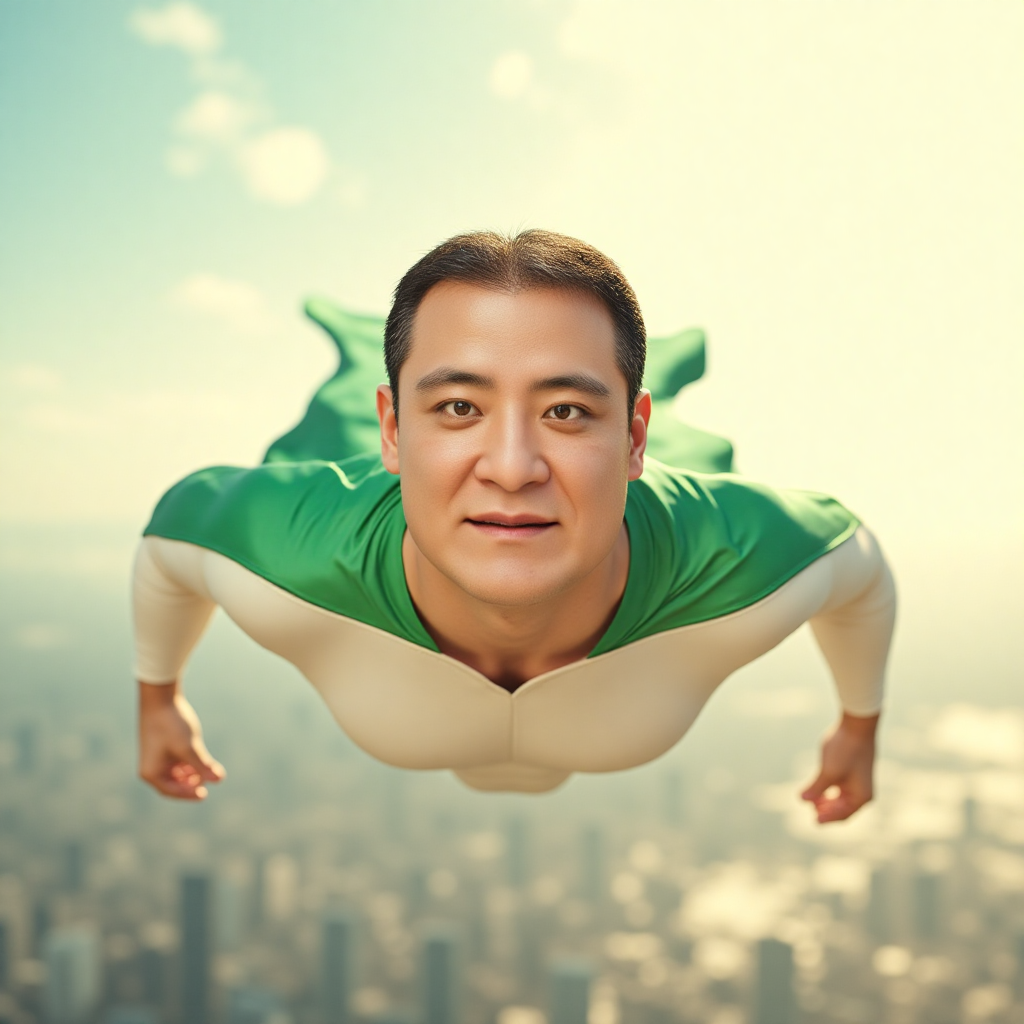

In [25]:
import os, pathlib
from IPython.display import Image, display, Markdown

out_dir = pathlib.Path(os.environ['OPENCLAW_HOME']) / '.openclaw/workspace/outputs'
pngs = sorted(out_dir.glob('superhero_*.png'), key=lambda p: p.stat().st_mtime, reverse=True)

if not pngs:
    print('❌ 还没有生成的图,先跑 5.1。')
else:
    latest = pngs[0]
    print(f'📁 共找到 {len(pngs)} 张生成图,显示最新一张:')
    print(f'   {latest}')
    display(Markdown('### 你的超级英雄照片 🦸'))
    display(Image(str(latest), width=512))

### 5.3 通过 OpenClaw 对话生成（终极测试 🎯）

打开第 3.3 节那条带 token 的 URL，按下面流程操作：

1. **先上传图片**（点输入框旁的回形针图标 📎），上传 `sample/sample_face.jpg` 或你自己的正面照
2. **再发文字**：「帮我生成超级英雄照片」
3. Agent 会调用 superhero skill（你能看到 stderr 进度），约 1 分钟后用 markdown 把生成图直接发回聊天

> ⚠️ **必须先附图再问**。如果只发"帮我生成超级英雄照片"而不附图，Qwen3.6 会
> 倾向给你介绍各种在线工具（Pixlio、Media.io 之类）而不是调用本地 skill——
> 即使我们在 SOUL.md 强化了规则，模型对"无图请求"的解读仍然不稳定。
>
> 如果模型还是没调 skill,可以直接把图片路径丢进对话框：
> 「用 superhero skill 生成超级英雄照片，照片在 /home/nvidia/build_a_claw_workshop/sample/sample_face.jpg」
> 这种明确指令模型 100% 会调。

如果一切顺利，你已经完成了**完全离线、完全本地**的多模态 Agent 闭环 🎉。

---

### 调试小贴士

| 现象 | 怎么看 |
|------|--------|
| Agent 完全不调用 skill | `bash scripts/openclaw-ctl.sh logs` 看 OpenClaw 日志；多半是 `SKILL.md` 描述太弱 |
| Agent 调用了 skill 但报错 | 命令行先单独跑 `run_helper.sh`，看 stderr 哪一步失败 |
| ComfyUI 卡死 | `bash scripts/comfyui-ctl.sh restart`；GPU 显存可能被其它模型占用 |
| 生成结果不像本人 | 用更清晰的正面照；PuLID `weight=1.0` 已经是最大 |


---

## 收尾 · 备忘单

```bash
# 整个 workshop 的所有命令都从 bundle 内部运行
cd /path/to/build_a_claw_workshop-bundle
source env.sh

# ComfyUI
bash scripts/comfyui-ctl.sh start | stop | restart | status | logs

# OpenClaw
bash scripts/openclaw-ctl.sh start | stop | restart | status | logs
./openclaw skills list           # 已加载 skill
./openclaw models set ollama/<model>   # 切换 LLM

# Ollama (系统服务)
sudo systemctl start | stop | restart ollama
ollama list

# 完全卸载（不影响系统其它部分）
bash scripts/comfyui-ctl.sh stop
bash scripts/openclaw-ctl.sh stop
sudo systemctl stop ollama && sudo systemctl disable ollama
sudo rm -rf /usr/local/{bin,lib}/ollama /usr/share/ollama /etc/systemd/system/ollama.service
rm -rf /path/to/build_a_claw_workshop-bundle
```

## 进一步玩

- **改 prompt**：编辑 `$OPENCLAW_HOME/skills/superhero/face_workflow.json` 节点 7 的正向 prompt，重启 OpenClaw。
- **加新 skill**：照 superhero 的样子在 `$OPENCLAW_HOME/skills/<your-skill>/` 复制一份，写 `SKILL.md` + `run_helper.sh` 即可。
- **接飞书 / 微信**：在 `$OPENCLAW_HOME/openclaw.json` 加 `channels.feishu` / `channels.openclaw-weixin`，按 OpenClaw 文档配 appId/appSecret。
- **换 LLM**：`ollama pull glm-4.7-flash` → `./openclaw models set ollama/glm-4.7-flash`。

🦸 **Happy hacking!**
